# Codebook-FIGS Ablation: Initialization, Refinement & Stability

This notebook demonstrates the **Codebook-FIGS** ablation experiment, which benchmarks:
- **3 initialization strategies**: PCA, Random, LDA-inspired
- **2 refinement strategies**: Weighted Least Squares (WLS), L-BFGS

= **6 configurations** evaluated on the breast cancer WDBC dataset with K-fold cross-validation.

**Key outputs:**
- Per-configuration accuracy with codebook stability (Hungarian-aligned cosine similarity)
- Convergence trajectories (effective rank, loss per round)
- Comparison with standard axis-aligned FIGS baseline

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# imodels — NOT on Colab, always install
_pip('imodels==2.0.4')

# Core packages — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlxtend 0.24.0 requires matplotlib>=3.10.8, but you have matplotlib 3.10.0 which is incompatible.
mlxtend 0.24.0 requires numpy>=2.3.5, but you have numpy 2.0.2 which is incompatible.
mlxtend 0.24.0 requires pandas>=2.3.3, but you have pandas 2.2.2 which is incompatible.
mlxtend 0.24.0 requires scikit-learn>=1.8.0, but you have scikit-learn 1.6.1 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple, Optional, Any

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-5c5e58-codebook-oblique-splits-learning-a-share/main/experiment_iter2_codebook_figs_a/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'])} dataset(s)")
for ds in data['datasets']:
    print(f"  {ds['dataset']}: {len(ds['examples'])} examples")

Loaded 1 dataset(s)
  breast_cancer_wdbc: 100 examples


## Configuration

All tunable parameters for the Codebook-FIGS ablation experiment.

In [5]:
# ── Tunable parameters ──────────────────────────────────────────────────────
# Original values: K=8, MAX_RULES=12, N_ALTERNATION_ROUNDS=5, N_FOLDS=5
K = 8                        # codebook size (number of oblique directions)
MAX_RULES = 12               # max splits per FIGS ensemble
N_ALTERNATION_ROUNDS = 5     # alternation rounds (grow trees, refine codebook)
N_FOLDS = 5                  # cross-validation folds
MIN_SAMPLES_LEAF = 5         # minimum samples per leaf node

INIT_STRATEGIES = ["pca", "random", "lda"]   # codebook initialization strategies
REFINE_STRATEGIES = ["wls", "lbfgs"]         # codebook refinement strategies

## Phase 0: Parse Datasets

Parse the loaded JSON data into numpy arrays with fold assignments.

In [6]:
def load_all_datasets(raw_data: dict) -> Dict[str, Dict]:
    """Load all datasets from the parsed JSON data.

    Returns dict keyed by dataset name with keys:
      X, y, folds, task_type, feature_names, n_features
    """
    datasets: Dict[str, Dict] = {}

    for group in raw_data["datasets"]:
        name = group["dataset"]
        if name.endswith("_mini"):
            continue
        examples = group["examples"]
        first = examples[0]
        task_type: str = first["metadata_task_type"]
        n_features: int = first.get("metadata_n_features", None)
        feature_names: List[str] = first.get("metadata_feature_names", [])

        X_list, y_list, fold_list = [], [], []
        for ex in examples:
            X_list.append(json.loads(ex["input"]))
            y_list.append(float(ex["output"]))
            fold_list.append(int(ex["metadata_fold"]))

        X = np.array(X_list, dtype=np.float64)
        y = np.array(y_list, dtype=np.float64)
        folds = np.array(fold_list, dtype=np.int32)

        if n_features is None:
            n_features = X.shape[1]

        datasets[name] = {
            "X": X,
            "y": y,
            "folds": folds,
            "task_type": task_type,
            "feature_names": feature_names,
            "n_features": n_features,
        }
        print(f"  {name}: {X.shape[0]} samples, {X.shape[1]} features, {task_type}")

    return datasets

datasets = load_all_datasets(data)
dataset_names = sorted(datasets.keys())
print(f"\nDatasets ({len(dataset_names)}): {dataset_names}")

  breast_cancer_wdbc: 100 samples, 30 features, classification

Datasets (1): ['breast_cancer_wdbc']


## Phase 1: Codebook-FIGS Core Implementation

Defines the `Node` class, codebook initialization strategies (PCA, Random, LDA), the split search, effective rank computation, and the full `CodebookFIGS` model with alternating tree-growing and codebook refinement.

In [7]:
class Node:
    """Tree node for Codebook-FIGS."""
    __slots__ = [
        "codebook_idx", "weights", "threshold", "value",
        "idxs", "left", "right", "left_temp", "right_temp",
        "impurity_reduction", "is_root", "tree_num", "depth", "n_samples",
    ]

    def __init__(self) -> None:
        self.codebook_idx: Optional[int] = None
        self.weights: Optional[np.ndarray] = None
        self.threshold: Optional[float] = None
        self.value: float = 0.0
        self.idxs: Optional[np.ndarray] = None
        self.left: Optional["Node"] = None
        self.right: Optional["Node"] = None
        self.left_temp: Optional["Node"] = None
        self.right_temp: Optional["Node"] = None
        self.impurity_reduction: Optional[float] = None
        self.is_root: bool = False
        self.tree_num: int = -1
        self.depth: int = 0
        self.n_samples: int = 0


# ── Codebook initialization strategies ──────────────────────────────────────

def init_codebook_pca(X_train: np.ndarray, K: int) -> np.ndarray:
    """PCA initialization: top-K principal components of X_train."""
    from sklearn.decomposition import PCA
    X_centered = X_train - X_train.mean(axis=0)
    K_actual = min(K, min(X_train.shape[0], X_train.shape[1]))
    pca = PCA(n_components=K_actual)
    pca.fit(X_centered)
    C = pca.components_.copy()
    if K_actual < K:
        rng = np.random.RandomState(42)
        extra = rng.randn(K - K_actual, X_train.shape[1])
        extra = extra / (np.linalg.norm(extra, axis=1, keepdims=True) + 1e-12)
        C = np.vstack([C, extra])
    norms = np.linalg.norm(C, axis=1, keepdims=True)
    C = C / np.maximum(norms, 1e-12)
    return C


def init_codebook_random(X_train: np.ndarray, K: int, random_state: int = 42) -> np.ndarray:
    """Random initialization: K random unit vectors from standard normal."""
    rng = np.random.RandomState(random_state)
    C = rng.randn(K, X_train.shape[1])
    C = C / (np.linalg.norm(C, axis=1, keepdims=True) + 1e-12)
    return C


def init_codebook_lda(
    X_train: np.ndarray,
    y_train: np.ndarray,
    K: int,
    task_type: str,
) -> np.ndarray:
    """LDA-inspired initialization via between-class scatter SVD."""
    try:
        if task_type == "regression":
            n_bins = min(10, max(2, len(np.unique(y_train)) // 2))
            from sklearn.preprocessing import KBinsDiscretizer
            kbd = KBinsDiscretizer(
                n_bins=n_bins, encode="ordinal", strategy="quantile",
            )
            y_binned = kbd.fit_transform(y_train.reshape(-1, 1)).ravel().astype(int)
        else:
            y_binned = y_train.astype(int)

        classes = np.unique(y_binned)
        n_features = X_train.shape[1]
        mu = X_train.mean(axis=0)

        S_B = np.zeros((n_features, n_features))
        for c in classes:
            mask = y_binned == c
            n_c = mask.sum()
            if n_c == 0:
                continue
            mu_c = X_train[mask].mean(axis=0)
            diff = mu_c - mu
            S_B += n_c * np.outer(diff, diff)

        _U, _S_vals, Vt = np.linalg.svd(S_B)
        n_lda = min(len(classes) - 1, n_features, K)
        n_lda = max(n_lda, 1)

        C_lda = Vt[:n_lda].copy()
        norms = np.linalg.norm(C_lda, axis=1, keepdims=True)
        C_lda = C_lda / np.maximum(norms, 1e-12)

        if n_lda < K:
            C_pca = init_codebook_pca(X_train, K)
            C = np.vstack([C_lda, C_pca[n_lda:K]])
        else:
            C = C_lda[:K]

        norms = np.linalg.norm(C, axis=1, keepdims=True)
        C = C / np.maximum(norms, 1e-12)
        return C
    except Exception:
        print("LDA init failed - falling back to PCA")
        return init_codebook_pca(X_train, K)


# ── Split search ─────────────────────────────────────────────────────────────

def find_best_codebook_split(
    X: np.ndarray,
    y_residuals: np.ndarray,
    idxs: np.ndarray,
    codebook: np.ndarray,
    min_samples_leaf: int = 5,
    quantile_threshold: int = 5000,
) -> Tuple[Optional[int], Optional[float], float, Optional[np.ndarray], Optional[np.ndarray]]:
    """Find the best (codebook direction, threshold) split."""
    node_indices = np.where(idxs)[0]
    n_node = len(node_indices)

    if n_node < 2 * min_samples_leaf:
        return None, None, -np.inf, None, None

    X_node = X[node_indices]
    y_node = y_residuals[node_indices]
    parent_var = np.var(y_node) * n_node

    best_k: Optional[int] = None
    best_threshold: Optional[float] = None
    best_reduction = -np.inf
    K = codebook.shape[0]

    use_quantiles = n_node > quantile_threshold
    n_quantiles = 100

    for k in range(K):
        proj = X_node @ codebook[k]
        order = np.argsort(proj)
        sorted_proj = proj[order]
        sorted_y = y_node[order]

        cum_sum = np.cumsum(sorted_y)
        cum_sq_sum = np.cumsum(sorted_y ** 2)
        total_sum = cum_sum[-1]
        total_sq_sum = cum_sq_sum[-1]

        if use_quantiles:
            positions = np.linspace(
                min_samples_leaf - 1,
                n_node - min_samples_leaf - 1,
                min(n_quantiles, n_node - 2 * min_samples_leaf),
            ).astype(int)
            positions = np.unique(positions)
        else:
            positions = np.arange(min_samples_leaf - 1, n_node - min_samples_leaf)

        for i in positions:
            if i + 1 < n_node and sorted_proj[i] == sorted_proj[i + 1]:
                continue

            n_left = i + 1
            n_right = n_node - n_left

            left_sum = cum_sum[i]
            right_sum = total_sum - left_sum

            left_mse = cum_sq_sum[i] - (left_sum ** 2) / n_left
            right_mse = (total_sq_sum - cum_sq_sum[i]) - (right_sum ** 2) / n_right

            reduction = parent_var - left_mse - right_mse

            if reduction > best_reduction:
                best_reduction = reduction
                best_k = k
                if i + 1 < n_node:
                    best_threshold = (sorted_proj[i] + sorted_proj[i + 1]) / 2.0
                else:
                    best_threshold = sorted_proj[i]

    if best_k is None:
        return None, None, -np.inf, None, None

    full_proj = X @ codebook[best_k]
    idxs_left = idxs & (full_proj <= best_threshold)
    idxs_right = idxs & (full_proj > best_threshold)

    return best_k, best_threshold, best_reduction, idxs_left, idxs_right


# ── Effective rank ───────────────────────────────────────────────────────────

def effective_rank(C: np.ndarray, eps: float = 1e-12) -> float:
    """Compute effective rank (eRank) of codebook matrix."""
    s = np.linalg.svd(C, compute_uv=False)
    s = s[s > eps]
    if len(s) == 0:
        return 0.0
    p = s / np.sum(s)
    entropy = -np.sum(p * np.log(p + 1e-30))
    return float(np.exp(entropy))

print("Phase 1 defined: Node, codebook init strategies, split search, effective rank")

Phase 1 defined: Node, codebook init strategies, split search, effective rank


### CodebookFIGS Model

The main model class that alternates between growing FIGS trees using codebook-constrained oblique splits and refining the codebook directions (via WLS or L-BFGS).

In [8]:
class CodebookFIGS:
    """Codebook-FIGS: FIGS with oblique splits constrained to a shared codebook."""

    def __init__(
        self,
        K: int = 8,
        max_rules: int = 12,
        max_trees: Optional[int] = None,
        min_impurity_decrease: float = 0.0,
        max_depth: Optional[int] = None,
        n_alternation_rounds: int = 5,
        init_strategy: str = "pca",
        refine_strategy: str = "wls",
        random_state: int = 42,
        min_samples_leaf: int = 5,
    ) -> None:
        self.K = K
        self.max_rules = max_rules
        self.max_trees = max_trees
        self.min_impurity_decrease = min_impurity_decrease
        self.max_depth = max_depth
        self.n_alternation_rounds = n_alternation_rounds
        self.init_strategy = init_strategy
        self.refine_strategy = refine_strategy
        self.random_state = random_state
        self.min_samples_leaf = min_samples_leaf

        self.trees_: List[Node] = []
        self.codebook_: Optional[np.ndarray] = None
        self.scaler_: Any = None
        self.task_type_: str = "classification"
        self.complexity_: int = 0
        self.history_: Dict[str, list] = {}
        self.converged_at_round_: int = 0

    def fit(self, X: np.ndarray, y: np.ndarray, task_type: str = "classification") -> "CodebookFIGS":
        from sklearn.preprocessing import StandardScaler

        n_samples, n_features = X.shape
        self.task_type_ = task_type

        self.scaler_ = StandardScaler()
        X_scaled = self.scaler_.fit_transform(X)

        if self.init_strategy == "pca":
            self.codebook_ = init_codebook_pca(X_scaled, self.K)
        elif self.init_strategy == "random":
            self.codebook_ = init_codebook_random(X_scaled, self.K, self.random_state)
        elif self.init_strategy == "lda":
            self.codebook_ = init_codebook_lda(X_scaled, y, self.K, task_type)
        else:
            raise ValueError(f"Unknown init_strategy: {self.init_strategy}")

        self.history_ = {
            "codebooks": [],
            "train_losses": [],
            "eranks": [],
            "n_splits": [],
            "accuracies": [],
        }

        initial_loss: Optional[float] = None

        for round_idx in range(self.n_alternation_rounds):
            self._grow_trees(X_scaled, y)

            preds = self._predict_raw(X_scaled)
            loss = float(np.mean((y - preds) ** 2))

            if task_type == "classification":
                acc = float(np.mean((preds >= 0.5).astype(int) == y.astype(int)))
                self.history_["accuracies"].append(acc)
            else:
                ss_res = np.sum((y - preds) ** 2)
                ss_tot = np.sum((y - y.mean()) ** 2)
                r2 = 1.0 - ss_res / max(ss_tot, 1e-12)
                self.history_["accuracies"].append(float(r2))

            self.history_["train_losses"].append(loss)
            self.history_["codebooks"].append(self.codebook_.copy())
            self.history_["eranks"].append(effective_rank(self.codebook_))
            self.history_["n_splits"].append(self.complexity_)

            if initial_loss is None:
                initial_loss = loss

            if round_idx < self.n_alternation_rounds - 1:
                if self.refine_strategy == "wls":
                    self._refine_codebook_wls(X_scaled, y)
                elif self.refine_strategy == "lbfgs":
                    self._refine_codebook_lbfgs(X_scaled, y)

                self._check_codebook_collapse()

                if len(self.history_["train_losses"]) >= 2 and initial_loss is not None:
                    loss_change = abs(
                        self.history_["train_losses"][-1] - self.history_["train_losses"][-2]
                    )
                    if initial_loss > 0 and loss_change < 0.01 * initial_loss:
                        self.converged_at_round_ = round_idx + 1
                        break

        if not hasattr(self, "converged_at_round_") or self.converged_at_round_ == 0:
            self.converged_at_round_ = len(self.history_["train_losses"])

        return self

    def _grow_trees(self, X: np.ndarray, y: np.ndarray) -> None:
        n_samples = X.shape[0]
        self.trees_ = []
        self.complexity_ = 0
        y_pred_per_tree: Dict[int, np.ndarray] = {}

        all_idxs = np.ones(n_samples, dtype=bool)
        initial_residuals = y.copy()

        best_k, best_t, best_red, idxs_l, idxs_r = find_best_codebook_split(
            X, initial_residuals, all_idxs, self.codebook_, self.min_samples_leaf,
        )

        if best_k is None:
            root = Node()
            root.is_root = True
            root.tree_num = 0
            root.idxs = all_idxs
            root.value = float(np.mean(y))
            root.n_samples = n_samples
            self.trees_.append(root)
            y_pred_per_tree[0] = np.full(n_samples, root.value)
            return

        root = Node()
        root.is_root = True
        root.tree_num = -1
        root.idxs = all_idxs
        root.value = float(np.mean(y))
        root.impurity_reduction = best_red
        root.codebook_idx = best_k
        root.weights = self.codebook_[best_k].copy()
        root.threshold = best_t
        root.depth = 0
        root.n_samples = n_samples

        root.left_temp = Node()
        root.left_temp.idxs = idxs_l
        root.left_temp.value = float(np.mean(initial_residuals[idxs_l])) if idxs_l.sum() > 0 else 0.0
        root.left_temp.n_samples = int(idxs_l.sum())
        root.left_temp.depth = 1

        root.right_temp = Node()
        root.right_temp.idxs = idxs_r
        root.right_temp.value = float(np.mean(initial_residuals[idxs_r])) if idxs_r.sum() > 0 else 0.0
        root.right_temp.n_samples = int(idxs_r.sum())
        root.right_temp.depth = 1

        potential_splits: List[Node] = [root]
        max_new_trees_per_round = 10

        while potential_splits and self.complexity_ < self.max_rules:
            potential_splits.sort(
                key=lambda n: n.impurity_reduction if n.impurity_reduction is not None else -np.inf,
                reverse=True,
            )
            best_node = potential_splits.pop(0)

            if best_node.impurity_reduction is None or best_node.impurity_reduction < self.min_impurity_decrease:
                break

            if self.max_depth is not None and best_node.depth >= self.max_depth:
                continue

            if best_node.is_root:
                if self.max_trees is not None and len(self.trees_) >= self.max_trees:
                    continue
                if len(self.trees_) >= max_new_trees_per_round:
                    continue
                best_node.tree_num = len(self.trees_)
                self.trees_.append(best_node)
                y_pred_per_tree[best_node.tree_num] = np.full(n_samples, best_node.value)

            self.complexity_ += 1
            best_node.left = best_node.left_temp
            best_node.right = best_node.right_temp
            best_node.left.tree_num = best_node.tree_num
            best_node.right.tree_num = best_node.tree_num
            best_node.left_temp = None
            best_node.right_temp = None

            tree_root = self.trees_[best_node.tree_num]
            y_pred_per_tree[best_node.tree_num] = self._predict_tree(tree_root, X)

            for child in [best_node.left, best_node.right]:
                if child.n_samples < 2 * self.min_samples_leaf:
                    continue

                t = child.tree_num
                y_residual = y.copy()
                for other_t, pred in y_pred_per_tree.items():
                    if other_t != t:
                        y_residual -= pred

                bk, bt, br, il, ir = find_best_codebook_split(
                    X, y_residual, child.idxs, self.codebook_, self.min_samples_leaf,
                )

                if bk is not None and br > self.min_impurity_decrease:
                    child.codebook_idx = bk
                    child.weights = self.codebook_[bk].copy()
                    child.threshold = bt
                    child.impurity_reduction = br

                    child.left_temp = Node()
                    child.left_temp.idxs = il
                    child.left_temp.value = float(np.mean(y_residual[il])) if il.sum() > 0 else 0.0
                    child.left_temp.n_samples = int(il.sum())
                    child.left_temp.depth = child.depth + 1

                    child.right_temp = Node()
                    child.right_temp.idxs = ir
                    child.right_temp.value = float(np.mean(y_residual[ir])) if ir.sum() > 0 else 0.0
                    child.right_temp.n_samples = int(ir.sum())
                    child.right_temp.depth = child.depth + 1

                    potential_splits.append(child)

            if len(self.trees_) < max_new_trees_per_round:
                y_total_pred = np.zeros(n_samples)
                for pred in y_pred_per_tree.values():
                    y_total_pred += pred
                y_res_new = y - y_total_pred

                bk, bt, br, il, ir = find_best_codebook_split(
                    X, y_res_new, np.ones(n_samples, dtype=bool), self.codebook_, self.min_samples_leaf,
                )

                if bk is not None and br > self.min_impurity_decrease:
                    new_root = Node()
                    new_root.is_root = True
                    new_root.tree_num = -1
                    new_root.idxs = np.ones(n_samples, dtype=bool)
                    new_root.value = float(np.mean(y_res_new))
                    new_root.impurity_reduction = br
                    new_root.codebook_idx = bk
                    new_root.weights = self.codebook_[bk].copy()
                    new_root.threshold = bt
                    new_root.depth = 0
                    new_root.n_samples = n_samples

                    new_root.left_temp = Node()
                    new_root.left_temp.idxs = il
                    new_root.left_temp.value = float(np.mean(y_res_new[il])) if il.sum() > 0 else 0.0
                    new_root.left_temp.n_samples = int(il.sum())
                    new_root.left_temp.depth = 1

                    new_root.right_temp = Node()
                    new_root.right_temp.idxs = ir
                    new_root.right_temp.value = float(np.mean(y_res_new[ir])) if ir.sum() > 0 else 0.0
                    new_root.right_temp.n_samples = int(ir.sum())
                    new_root.right_temp.depth = 1

                    potential_splits.append(new_root)

    def _predict_tree(self, root: Node, X: np.ndarray) -> np.ndarray:
        preds = np.full(X.shape[0], root.value)
        if root.left is not None and root.right is not None:
            proj = X @ root.weights
            left_mask = proj <= root.threshold
            right_mask = ~left_mask
            left_preds = self._predict_tree(root.left, X)
            right_preds = self._predict_tree(root.right, X)
            preds[left_mask] = left_preds[left_mask]
            preds[right_mask] = right_preds[right_mask]
        return preds

    def _predict_raw(self, X: np.ndarray) -> np.ndarray:
        if not self.trees_:
            return np.zeros(X.shape[0])
        preds = np.zeros(X.shape[0])
        for tree in self.trees_:
            preds += self._predict_tree(tree, X)
        return preds

    def predict(self, X_raw: np.ndarray) -> np.ndarray:
        X = self.scaler_.transform(X_raw)
        raw = self._predict_raw(X)
        if self.task_type_ == "classification":
            return (raw >= 0.5).astype(int)
        return raw

    def predict_proba(self, X_raw: np.ndarray) -> np.ndarray:
        X = self.scaler_.transform(X_raw)
        raw = self._predict_raw(X)
        probs = np.clip(raw, 0.0, 1.0)
        return np.column_stack([1 - probs, probs])

    def _collect_nodes_with_codebook_idx(
        self, node: Optional[Node], k: int, result_list: List[Node],
    ) -> None:
        if node is None:
            return
        if node.left is not None and node.right is not None:
            if node.codebook_idx == k:
                result_list.append(node)
            self._collect_nodes_with_codebook_idx(node.left, k, result_list)
            self._collect_nodes_with_codebook_idx(node.right, k, result_list)

    def _refine_codebook_wls(self, X: np.ndarray, y: np.ndarray) -> None:
        K = self.codebook_.shape[0]
        n_features = self.codebook_.shape[1]

        for k in range(K):
            nodes_k: List[Node] = []
            for tree in self.trees_:
                self._collect_nodes_with_codebook_idx(tree, k, nodes_k)

            if len(nodes_k) == 0:
                rng = np.random.RandomState(self.random_state + k)
                self.codebook_[k] = rng.randn(n_features)
                self.codebook_[k] /= np.linalg.norm(self.codebook_[k]) + 1e-12
                continue

            all_X_pooled: List[np.ndarray] = []
            all_y_residual_pooled: List[np.ndarray] = []

            for node in nodes_k:
                y_res = y.copy()
                for t_idx, tree in enumerate(self.trees_):
                    if t_idx != node.tree_num:
                        y_res -= self._predict_tree(tree, X)
                node_mask = node.idxs
                all_X_pooled.append(X[node_mask])
                all_y_residual_pooled.append(y_res[node_mask])

            X_pool = np.vstack(all_X_pooled)
            y_pool = np.concatenate(all_y_residual_pooled)

            direction = X_pool.T @ y_pool
            norm = np.linalg.norm(direction)
            if norm > 1e-12:
                self.codebook_[k] = direction / norm

    def _refine_codebook_lbfgs(self, X: np.ndarray, y: np.ndarray) -> None:
        from scipy.optimize import minimize

        K = self.codebook_.shape[0]
        n_features = self.codebook_.shape[1]
        msl = self.min_samples_leaf

        for k in range(K):
            nodes_k: List[Node] = []
            for tree in self.trees_:
                self._collect_nodes_with_codebook_idx(tree, k, nodes_k)

            if len(nodes_k) == 0:
                rng = np.random.RandomState(self.random_state + k)
                self.codebook_[k] = rng.randn(n_features)
                self.codebook_[k] /= np.linalg.norm(self.codebook_[k]) + 1e-12
                continue

            node_data: List[Tuple[np.ndarray, np.ndarray]] = []
            for node in nodes_k:
                y_res = y.copy()
                for t_idx, tree in enumerate(self.trees_):
                    if t_idx != node.tree_num:
                        y_res -= self._predict_tree(tree, X)
                node_data.append((X[node.idxs], y_res[node.idxs]))

            def neg_impurity_reduction(c_flat: np.ndarray) -> float:
                c = c_flat / (np.linalg.norm(c_flat) + 1e-12)
                total_reduction = 0.0
                for X_node, y_node in node_data:
                    n = len(y_node)
                    if n < 2 * msl:
                        continue
                    proj = X_node @ c
                    parent_var = np.var(y_node) * n
                    order = np.argsort(proj)
                    sy = y_node[order]
                    cs_y = np.cumsum(sy)
                    css_y = np.cumsum(sy ** 2)
                    best_red = -np.inf
                    positions = np.linspace(msl - 1, n - msl - 1, min(50, n - 2 * msl)).astype(int)
                    positions = np.unique(positions)
                    for i in positions:
                        nl = i + 1
                        nr = n - nl
                        l_mse = css_y[i] - cs_y[i] ** 2 / nl
                        r_mse = (css_y[-1] - css_y[i]) - (cs_y[-1] - cs_y[i]) ** 2 / nr
                        red = parent_var - l_mse - r_mse
                        if red > best_red:
                            best_red = red
                    total_reduction += best_red if best_red > -np.inf else 0.0
                return -total_reduction

            c0 = self.codebook_[k].copy()
            try:
                result = minimize(
                    neg_impurity_reduction, c0, method="L-BFGS-B",
                    jac="2-point",
                    options={"maxiter": 30, "ftol": 1e-6, "eps": 1e-5},
                )
                c_new = result.x
                norm = np.linalg.norm(c_new)
                if norm > 1e-12:
                    self.codebook_[k] = c_new / norm
            except Exception:
                pass  # keep existing direction

    def _check_codebook_collapse(self) -> int:
        """Check for collapsed codebook entries and reinitialize."""
        from sklearn.metrics.pairwise import cosine_similarity
        K = self.codebook_.shape[0]
        n_features = self.codebook_.shape[1]
        cos_sim = np.abs(cosine_similarity(self.codebook_))
        np.fill_diagonal(cos_sim, 0.0)
        n_collapses = 0
        for i in range(K):
            for j in range(i + 1, K):
                if cos_sim[i, j] > 0.99:
                    rng = np.random.RandomState(self.random_state + 100 + j)
                    self.codebook_[j] = rng.randn(n_features)
                    self.codebook_[j] /= np.linalg.norm(self.codebook_[j]) + 1e-12
                    n_collapses += 1
        return n_collapses

print("CodebookFIGS class defined")

CodebookFIGS class defined


## Phase 2: Metrics & Evaluation

Codebook alignment via Hungarian algorithm, stability computation, and fold-level evaluation functions.

In [9]:
def align_codebooks_hungarian(
    C_ref: np.ndarray, C_target: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Align C_target to C_ref using Hungarian algorithm on |cosine similarity|."""
    from scipy.optimize import linear_sum_assignment
    from sklearn.metrics.pairwise import cosine_similarity

    cos_sim = cosine_similarity(C_ref, C_target)
    abs_cos_sim = np.abs(cos_sim)

    row_ind, col_ind = linear_sum_assignment(abs_cos_sim, maximize=True)

    C_aligned = C_target[col_ind].copy()
    matched_sims = []
    for i in range(len(row_ind)):
        sim = cos_sim[row_ind[i], col_ind[i]]
        matched_sims.append(abs(sim))
        if sim < 0:
            C_aligned[i] *= -1

    return C_aligned, col_ind, np.array(matched_sims)


def compute_codebook_stability(codebooks: List[np.ndarray]) -> Dict[str, Any]:
    """Compute codebook stability across CV folds."""
    if len(codebooks) < 2:
        return {
            "mean_cosine_sim": 1.0,
            "min_cosine_sim": 1.0,
            "per_entry_mean_sim": [1.0] * codebooks[0].shape[0],
            "per_entry_std_sim": [0.0] * codebooks[0].shape[0],
        }

    C_ref = codebooks[0]
    all_sims = []
    for fold_idx in range(1, len(codebooks)):
        _, _, sims = align_codebooks_hungarian(C_ref, codebooks[fold_idx])
        all_sims.append(sims)

    all_sims_arr = np.array(all_sims)
    return {
        "mean_cosine_sim": float(np.mean(all_sims_arr)),
        "min_cosine_sim": float(np.min(all_sims_arr)),
        "per_entry_mean_sim": all_sims_arr.mean(axis=0).tolist(),
        "per_entry_std_sim": all_sims_arr.std(axis=0).tolist(),
    }


def evaluate_fold_codebook(
    model: CodebookFIGS,
    X_test: np.ndarray,
    y_test: np.ndarray,
    task_type: str,
) -> Dict[str, Any]:
    """Evaluate CodebookFIGS on one fold's test set."""
    if task_type == "classification":
        y_pred = model.predict(X_test)
        accuracy = float(np.mean(y_pred == y_test.astype(int)))
        try:
            from sklearn.metrics import roc_auc_score
            y_prob = model.predict_proba(X_test)[:, 1]
            auc = float(roc_auc_score(y_test.astype(int), y_prob))
        except Exception:
            auc = None
        return {"accuracy": accuracy, "auc": auc}
    else:
        y_pred = model.predict(X_test)
        mse = float(np.mean((y_test - y_pred) ** 2))
        ss_res = float(np.sum((y_test - y_pred) ** 2))
        ss_tot = float(np.sum((y_test - y_test.mean()) ** 2))
        r2 = 1.0 - ss_res / max(ss_tot, 1e-12)
        return {"mse": mse, "r2": float(r2)}


def evaluate_fold_sklearn(
    model: Any,
    X_test: np.ndarray,
    y_test: np.ndarray,
    task_type: str,
) -> Dict[str, Any]:
    """Evaluate a sklearn-compatible model on one fold's test set."""
    if task_type == "classification":
        y_pred = model.predict(X_test)
        accuracy = float(np.mean(y_pred == y_test.astype(int)))
        try:
            from sklearn.metrics import roc_auc_score
            y_prob = model.predict_proba(X_test)[:, 1]
            auc = float(roc_auc_score(y_test.astype(int), y_prob))
        except Exception:
            auc = None
        return {"accuracy": accuracy, "auc": auc}
    else:
        y_pred = model.predict(X_test)
        mse = float(np.mean((y_test - y_pred) ** 2))
        ss_res = float(np.sum((y_test - y_pred) ** 2))
        ss_tot = float(np.sum((y_test - y_test.mean()) ** 2))
        r2 = 1.0 - ss_res / max(ss_tot, 1e-12)
        return {"mse": mse, "r2": float(r2)}


def aggregate_fold_metrics(
    fold_metrics: List[Dict[str, Any]], task_type: str,
) -> Dict[str, Any]:
    """Aggregate metrics across folds."""
    if task_type == "classification":
        accs = [m["accuracy"] for m in fold_metrics]
        aucs = [m["auc"] for m in fold_metrics if m.get("auc") is not None]
        result = {
            "mean_accuracy": float(np.mean(accs)),
            "std_accuracy": float(np.std(accs)),
        }
        if aucs:
            result["mean_auc"] = float(np.mean(aucs))
            result["std_auc"] = float(np.std(aucs))
        else:
            result["mean_auc"] = None
            result["std_auc"] = None
        return result
    else:
        mses = [m["mse"] for m in fold_metrics]
        r2s = [m["r2"] for m in fold_metrics]
        return {
            "mean_mse": float(np.mean(mses)),
            "std_mse": float(np.std(mses)),
            "mean_r2": float(np.mean(r2s)),
            "std_r2": float(np.std(r2s)),
        }

print("Phase 2 defined: alignment, stability, evaluation functions")

Phase 2 defined: alignment, stability, evaluation functions


## Phase 3: Run Codebook-FIGS Ablation & FIGS Baseline

Run all 6 configurations (3 init x 2 refine) with cross-validation, then run the standard axis-aligned FIGS baseline for comparison.

In [10]:
def run_codebook_figs_ablation(
    datasets: Dict[str, Dict],
    dataset_names: List[str],
    K: int = 8,
    max_rules: int = 12,
    n_alternation_rounds: int = 5,
    n_folds: int = 5,
) -> Tuple[Dict[str, Dict], Dict[str, Dict[str, np.ndarray]]]:
    """Run full Codebook-FIGS ablation across datasets and configs."""
    results: Dict[str, Dict] = {}
    all_predictions: Dict[str, Dict[str, np.ndarray]] = {}

    for ds_name in dataset_names:
        print(f"=== Dataset: {ds_name} ===")
        ds = datasets[ds_name]
        X, y, folds, task_type = ds["X"], ds["y"], ds["folds"], ds["task_type"]
        n_samples = X.shape[0]

        unique_folds = sorted(np.unique(folds))
        actual_n_folds = min(n_folds, len(unique_folds))
        fold_splits = []
        for fold_id in unique_folds[:actual_n_folds]:
            test_mask = folds == fold_id
            train_mask = ~test_mask
            fold_splits.append((train_mask, test_mask))

        dataset_results: Dict[str, Dict] = {}
        ds_predictions: Dict[str, np.ndarray] = {}

        for init_strat in INIT_STRATEGIES:
            for refine_strat in REFINE_STRATEGIES:
                config_name = f"{init_strat}_{refine_strat}"
                print(f"  Config: {config_name}")
                t0 = time.time()

                fold_metrics: List[Dict] = []
                fold_codebooks: List[np.ndarray] = []
                fold_histories: List[Dict] = []
                fold_converged_rounds: List[int] = []
                oof_preds = np.full(n_samples, np.nan)

                for fold_id in range(actual_n_folds):
                    train_mask, test_mask = fold_splits[fold_id]
                    X_train, y_train = X[train_mask], y[train_mask]
                    X_test, y_test = X[test_mask], y[test_mask]

                    model = CodebookFIGS(
                        K=K,
                        max_rules=max_rules,
                        n_alternation_rounds=n_alternation_rounds,
                        init_strategy=init_strat,
                        refine_strategy=refine_strat,
                        random_state=42 + fold_id,
                        min_samples_leaf=MIN_SAMPLES_LEAF,
                    )

                    try:
                        model.fit(X_train, y_train, task_type=task_type)
                        metrics = evaluate_fold_codebook(model, X_test, y_test, task_type)
                        y_pred_test = model.predict(X_test)
                        oof_preds[test_mask] = y_pred_test
                    except Exception as e:
                        print(f"    Failed on {ds_name}/{config_name}/fold{fold_id}: {e}")
                        if task_type == "classification":
                            metrics = {"accuracy": 0.0, "auc": None}
                        else:
                            metrics = {"mse": 1e6, "r2": -1.0}
                        model = CodebookFIGS(K=K)
                        model.codebook_ = np.eye(K, X.shape[1])[:K]
                        model.history_ = {"train_losses": [0], "eranks": [1], "n_splits": [0], "accuracies": [0], "codebooks": []}
                        model.converged_at_round_ = 0

                    fold_metrics.append(metrics)
                    if model.codebook_ is not None:
                        fold_codebooks.append(model.codebook_.copy())
                    fold_histories.append(model.history_)
                    fold_converged_rounds.append(model.converged_at_round_)

                nan_mask = np.isnan(oof_preds)
                if nan_mask.any():
                    oof_preds[nan_mask] = np.nanmean(oof_preds) if not np.all(nan_mask) else 0.0
                ds_predictions[config_name] = oof_preds

                agg_metrics = aggregate_fold_metrics(fold_metrics, task_type)

                if len(fold_codebooks) >= 2:
                    stability = compute_codebook_stability(fold_codebooks)
                else:
                    stability = {
                        "mean_cosine_sim": None, "min_cosine_sim": None,
                        "per_entry_mean_sim": [], "per_entry_std_sim": [],
                    }

                convergence = {
                    "mean_converged_round": float(np.mean(fold_converged_rounds)),
                    "per_fold_converged_round": [int(r) for r in fold_converged_rounds],
                    "per_fold_loss_trajectories": [h.get("train_losses", []) for h in fold_histories],
                    "per_fold_erank_trajectories": [h.get("eranks", []) for h in fold_histories],
                    "per_fold_accuracy_trajectories": [h.get("accuracies", []) for h in fold_histories],
                }

                elapsed = time.time() - t0
                print(f"    {config_name} done in {elapsed:.1f}s | {agg_metrics}")

                dataset_results[config_name] = {
                    "per_fold_metrics": fold_metrics,
                    "aggregate_metrics": agg_metrics,
                    "codebook_stability": stability,
                    "convergence": convergence,
                    "final_erank_per_fold": [h["eranks"][-1] if h.get("eranks") else 0 for h in fold_histories],
                    "n_splits_per_fold": [h["n_splits"][-1] if h.get("n_splits") else 0 for h in fold_histories],
                    "time_seconds": round(elapsed, 2),
                }

        results[ds_name] = dataset_results
        all_predictions[ds_name] = ds_predictions

    return results, all_predictions


def run_figs_baseline(
    datasets: Dict[str, Dict],
    dataset_names: List[str],
    max_rules: int = 12,
    n_folds: int = 5,
) -> Tuple[Dict[str, Dict], Dict[str, np.ndarray]]:
    """Run standard axis-aligned FIGS baseline using imodels."""
    figs_predictions: Dict[str, np.ndarray] = {}

    try:
        from imodels import FIGSClassifier, FIGSRegressor
        print("imodels loaded successfully")
    except ImportError:
        print("imodels not available - skipping FIGS baseline")
        return {"status": "imodels_not_available"}, {}

    figs_results: Dict[str, Dict] = {}

    for ds_name in dataset_names:
        print(f"  FIGS baseline: {ds_name}")
        ds = datasets[ds_name]
        X, y, folds, task_type = ds["X"], ds["y"], ds["folds"], ds["task_type"]
        n_samples = X.shape[0]

        unique_folds = sorted(np.unique(folds))
        actual_n_folds = min(n_folds, len(unique_folds))
        fold_metrics: List[Dict] = []
        oof_preds = np.full(n_samples, np.nan)

        for fold_id in unique_folds[:actual_n_folds]:
            test_mask = folds == fold_id
            train_mask = ~test_mask
            X_train, y_train = X[train_mask], y[train_mask]
            X_test, y_test = X[test_mask], y[test_mask]

            try:
                if task_type == "classification":
                    figs_model = FIGSClassifier(max_rules=max_rules)
                else:
                    figs_model = FIGSRegressor(max_rules=max_rules)

                figs_model.fit(X_train, y_train)
                metrics = evaluate_fold_sklearn(figs_model, X_test, y_test, task_type)
                y_pred_test = figs_model.predict(X_test)
                oof_preds[test_mask] = y_pred_test
            except Exception as e:
                print(f"    FIGS baseline failed on {ds_name}/fold{fold_id}: {e}")
                if task_type == "classification":
                    metrics = {"accuracy": 0.0, "auc": None}
                else:
                    metrics = {"mse": 1e6, "r2": -1.0}

            fold_metrics.append(metrics)

        nan_mask = np.isnan(oof_preds)
        if nan_mask.any():
            oof_preds[nan_mask] = np.nanmean(oof_preds) if not np.all(nan_mask) else 0.0
        figs_predictions[ds_name] = oof_preds

        agg = aggregate_fold_metrics(fold_metrics, task_type)
        figs_results[ds_name] = {
            "per_fold_metrics": fold_metrics,
            "aggregate_metrics": agg,
        }
        print(f"    FIGS baseline {ds_name}: {agg}")

    return figs_results, figs_predictions

print("Phase 3 defined: ablation runner and FIGS baseline")

Phase 3 defined: ablation runner and FIGS baseline


## Run Experiment

Execute the Codebook-FIGS ablation and FIGS baseline.

In [11]:
t_start = time.time()

# Run Codebook-FIGS ablation
print("Starting Codebook-FIGS ablation...")
codebook_results, codebook_predictions = run_codebook_figs_ablation(
    datasets, dataset_names,
    K=K, max_rules=MAX_RULES,
    n_alternation_rounds=N_ALTERNATION_ROUNDS,
    n_folds=N_FOLDS,
)
t_codebook = time.time()
print(f"\nCodebook-FIGS ablation done in {t_codebook - t_start:.1f}s")

# Run FIGS baseline
print("\nStarting FIGS baseline...")
figs_results, figs_predictions = run_figs_baseline(
    datasets, dataset_names,
    max_rules=MAX_RULES, n_folds=N_FOLDS,
)
t_figs = time.time()
print(f"FIGS baseline done in {t_figs - t_codebook:.1f}s")
print(f"\nTotal experiment time: {t_figs - t_start:.1f}s")

Starting Codebook-FIGS ablation...
=== Dataset: breast_cancer_wdbc ===
  Config: pca_wls


    pca_wls done in 1.6s | {'mean_accuracy': 0.9099999999999999, 'std_accuracy': 0.037416573867739396, 'mean_auc': 0.9620000000000001, 'std_auc': 0.021118712081942857}
  Config: pca_lbfgs


    pca_lbfgs done in 1.3s | {'mean_accuracy': 0.9, 'std_accuracy': 0.06324555320336757, 'mean_auc': 0.9710000000000001, 'std_auc': 0.021540659228538008}
  Config: random_wls


    random_wls done in 0.7s | {'mean_accuracy': 0.9200000000000002, 'std_accuracy': 0.024494897427831747, 'mean_auc': 0.9199999999999999, 'std_auc': 0.02144761058952721}
  Config: random_lbfgs


    random_lbfgs done in 1.3s | {'mean_accuracy': 0.8800000000000001, 'std_accuracy': 0.07483314773547882, 'mean_auc': 0.923, 'std_auc': 0.0457820925690384}
  Config: lda_wls


    lda_wls done in 0.8s | {'mean_accuracy': 0.93, 'std_accuracy': 0.024494897427831747, 'mean_auc': 0.9620000000000001, 'std_auc': 0.02039607805437114}
  Config: lda_lbfgs


    lda_lbfgs done in 1.6s | {'mean_accuracy': 0.97, 'std_accuracy': 0.024494897427831803, 'mean_auc': 0.9720000000000001, 'std_auc': 0.022934689882359412}

Codebook-FIGS ablation done in 7.4s

Starting FIGS baseline...


imodels loaded successfully
  FIGS baseline: breast_cancer_wdbc
    FIGS baseline breast_cancer_wdbc: {'mean_accuracy': 0.85, 'std_accuracy': 0.031622776601683784, 'mean_auc': 0.85, 'std_auc': 0.031622776601683784}
FIGS baseline done in 0.3s

Total experiment time: 7.7s


## Results & Visualization

Summary table of all configurations, convergence trajectories, and codebook stability analysis.

CODEBOOK-FIGS ABLATION RESULTS

--- breast_cancer_wdbc (classification) ---
Config              Score      Std  Stability    eRank   Time
------------------------------------------------------------
pca_wls            0.9100   0.0374      0.653     6.53   1.6s
pca_lbfgs          0.9000   0.0632      0.539     7.80   1.3s
random_wls         0.9200   0.0245      0.647     6.23   0.7s
random_lbfgs       0.8800   0.0748      0.461     7.74   1.3s
lda_wls            0.9300   0.0245      0.602     6.94   0.8s
lda_lbfgs          0.9700   0.0245      0.609     7.77   1.6s

--- FIGS Baseline ---
  breast_cancer_wdbc: mean_accuracy=0.8500


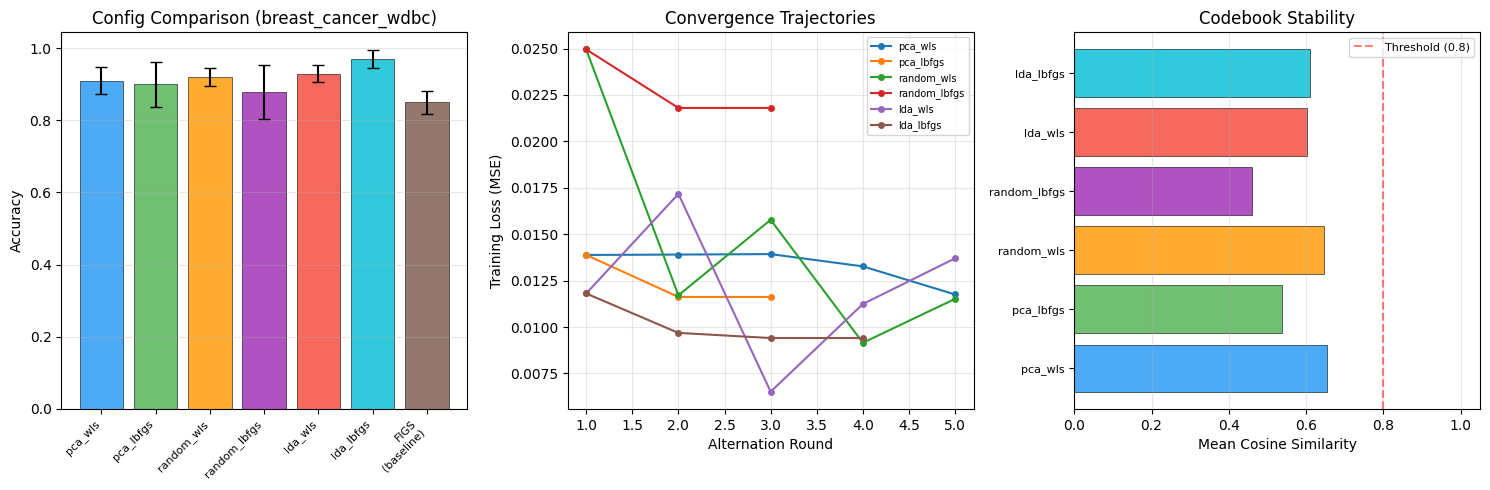


Visualization saved to results.png


In [12]:
# ── Results Summary Table ────────────────────────────────────────────────────
print("=" * 70)
print("CODEBOOK-FIGS ABLATION RESULTS")
print("=" * 70)

for ds_name in dataset_names:
    ds_results = codebook_results[ds_name]
    task_type = datasets[ds_name]["task_type"]
    metric_key = "mean_accuracy" if task_type == "classification" else "mean_r2"
    std_key = "std_accuracy" if task_type == "classification" else "std_r2"

    print(f"\n--- {ds_name} ({task_type}) ---")
    print(f"{'Config':<16} {'Score':>8} {'Std':>8} {'Stability':>10} {'eRank':>8} {'Time':>6}")
    print("-" * 60)

    for config_name, config_data in ds_results.items():
        agg = config_data["aggregate_metrics"]
        score = agg.get(metric_key, 0.0)
        std = agg.get(std_key, 0.0)
        stab = config_data["codebook_stability"].get("mean_cosine_sim", None)
        stab_str = f"{stab:.3f}" if stab is not None else "N/A"
        eranks = config_data["final_erank_per_fold"]
        mean_erank = np.mean(eranks) if eranks else 0
        elapsed = config_data["time_seconds"]
        print(f"{config_name:<16} {score:>8.4f} {std:>8.4f} {stab_str:>10} {mean_erank:>8.2f} {elapsed:>5.1f}s")

# FIGS baseline
if isinstance(figs_results, dict) and "status" not in figs_results:
    print(f"\n--- FIGS Baseline ---")
    for ds_name in dataset_names:
        if ds_name in figs_results:
            task_type = datasets[ds_name]["task_type"]
            metric_key = "mean_accuracy" if task_type == "classification" else "mean_r2"
            agg = figs_results[ds_name]["aggregate_metrics"]
            score = agg.get(metric_key, 0.0)
            print(f"  {ds_name}: {metric_key}={score:.4f}")

# ── Visualization ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Accuracy comparison across configs
ds_name = dataset_names[0]
ds_results = codebook_results[ds_name]
task_type = datasets[ds_name]["task_type"]
metric_key = "mean_accuracy" if task_type == "classification" else "mean_r2"
std_key = "std_accuracy" if task_type == "classification" else "std_r2"

config_names = list(ds_results.keys())
scores = [ds_results[c]["aggregate_metrics"].get(metric_key, 0) for c in config_names]
stds = [ds_results[c]["aggregate_metrics"].get(std_key, 0) for c in config_names]

# Add FIGS baseline if available
if isinstance(figs_results, dict) and ds_name in figs_results:
    config_names.append("FIGS\n(baseline)")
    scores.append(figs_results[ds_name]["aggregate_metrics"].get(metric_key, 0))
    stds.append(figs_results[ds_name]["aggregate_metrics"].get(std_key, 0))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336', '#00BCD4', '#795548']
bars = axes[0].bar(range(len(config_names)), scores, yerr=stds, capsize=4,
                   color=colors[:len(config_names)], alpha=0.8, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(len(config_names)))
axes[0].set_xticklabels(config_names, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel(metric_key.replace("mean_", "").replace("_", " ").title())
axes[0].set_title(f"Config Comparison ({ds_name})")
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Convergence trajectories (loss) — handle variable-length trajectories
for config_name, config_data in codebook_results[ds_name].items():
    conv = config_data["convergence"]
    trajectories = conv["per_fold_loss_trajectories"]
    valid_trajs = [t for t in trajectories if len(t) > 0]
    if valid_trajs:
        max_len = max(len(t) for t in valid_trajs)
        # Pad shorter trajectories by repeating last value
        padded = []
        for t in valid_trajs:
            padded.append(t + [t[-1]] * (max_len - len(t)))
        mean_traj = np.mean(padded, axis=0)
        axes[1].plot(range(1, len(mean_traj) + 1), mean_traj, marker='o', label=config_name, markersize=4)

axes[1].set_xlabel("Alternation Round")
axes[1].set_ylabel("Training Loss (MSE)")
axes[1].set_title("Convergence Trajectories")
axes[1].legend(fontsize=7, loc='best')
axes[1].grid(alpha=0.3)

# Plot 3: Codebook stability
stabilities = []
stab_labels = []
for config_name, config_data in codebook_results[ds_name].items():
    stab = config_data["codebook_stability"].get("mean_cosine_sim")
    if stab is not None:
        stabilities.append(stab)
        stab_labels.append(config_name)

if stabilities:
    bars = axes[2].barh(range(len(stab_labels)), stabilities,
                        color=colors[:len(stab_labels)], alpha=0.8, edgecolor='black', linewidth=0.5)
    axes[2].set_yticks(range(len(stab_labels)))
    axes[2].set_yticklabels(stab_labels, fontsize=8)
    axes[2].set_xlabel("Mean Cosine Similarity")
    axes[2].set_title("Codebook Stability")
    axes[2].axvline(x=0.8, color='red', linestyle='--', alpha=0.5, label='Threshold (0.8)')
    axes[2].set_xlim(0, 1.05)
    axes[2].legend(fontsize=8)
    axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig("results.png", dpi=100, bbox_inches='tight')
plt.show()
print("\nVisualization saved to results.png")